# Data Preprocessing

## Import required packages

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import keras_tuner as kt
import matplotlib.pyplot as plt
from tcn import TCN
from collections import Counter
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.saving import save_model
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

## Import dataset with windowing and labelling

In [2]:
dataset_path = './dataset20'
classes = ["bungkuk", "duduk", "jatoh", "jongkok"]
timesteps = 30

data = []
labels = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    for subject_folder in os.listdir(class_path):  # Iterate through subjects
        subject_path = os.path.join(class_path, subject_folder)
        if os.path.isdir(subject_path):  # Check if it's a folder
            for file_name in os.listdir(subject_path):  # Iterate through files in the subject folder
                file_path = os.path.join(subject_path, file_name)
                # Load the data file (excluding timestamp column)
                sequence = pd.read_csv(file_path).iloc[:, 1:].to_numpy()  # Exclude timestamp
                # Ensure the data has enough timesteps
                if len(sequence) >= timesteps:
                    for i in range(len(sequence) - timesteps + 1):
                        data.append(sequence[i:i + timesteps])
                        # Assign label 1 if class is 'jatuh', else 0
                        label = 1 if class_name.lower() == "jatoh" else 0
                        labels.append(label)

## Normalize and split data

In [ ]:
# Convert to numpy arrays
data = np.array(data)
labels = np.array(labels)

# One-hot encode the labels
labels = to_categorical(labels, num_classes=2)

# Normalize the data
scaler = StandardScaler()
data_reshaped = data.reshape(-1, data.shape[-1]) # Flatten for scaling
data_scaled = scaler.fit_transform(data_reshaped).reshape(data.shape)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data_scaled, labels,test_size=0.2, random_state=42)

In [11]:
joblib.dump(scaler, './TCN_scaler.pkl')

['./TCN_scaler.pkl']

In [4]:
print(len(data))
print(len(labels))
print(data.shape)
print(labels.shape)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

32519
32519
(32519, 30, 9)
(32519, 2)
(26015, 30, 9)
(26015, 2)
(6504, 30, 9)
(6504, 2)


# Building TCN Model

## Defining TCN model

In [ ]:
def build_model(hp):
    filters = hp.Int("filters", 32, 192, step=16)
    kernel_size = hp.Choice("kernel_size", [2, 3, 4, 5])
    units = hp.Int("units", 32, 128, step=16)
    activation = hp.Choice("activation", ["relu", "tanh"])
    optimizer = hp.Choice("optimizer", ["adam", "rmsprop", "nadam"])

    model = Sequential([
        TCN(
            input_shape=(timesteps, 9),
            nb_filters=filters,
            kernel_size=kernel_size,
            dilations=[1, 2, 4, 8],
            dropout_rate=0.05,
            return_sequences=False
        ),
        Dense(units, activation=activation),
        Dense(2, activation='softmax'),
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Hyperparameter tuning

In [ ]:
tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=40,
    factor=3,
    directory=f"/content/drive/MyDrive/Colab Notebooks/TS_{timesteps}",
    project_name="TCN_tuning"
)

tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test), batch_size=32)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

print(f"""
The optimal number of filters is: {best_hps.get('filters')}
The optimal kernel size is: {best_hps.get('kernel_size')}
The optimal number of units in the TCN layer is: {best_hps.get('units')}
The optimal activation function is: {best_hps.get('activation')}
The optimal optimizer is: {best_hps.get('optimizer')}
""")

test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

best_model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), batch_size=32)

Trial 84 Complete [01h 19m 11s]
val_accuracy: 0.733241081237793

Best val_accuracy So Far: 0.9996924996376038
Total elapsed time: 19h 08m 00s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 47 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



The optimal number of filters is: 128
The optimal kernel size is: 3
The optimal number of units in the TCN layer is: 64
The optimal activation function is: relu
The optimal optimizer is: nadam

204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 1.0000 - loss: 0.0017
Test Accuracy: 99.97%
Epoch 1/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 84s 95ms/step - accuracy: 0.9971 - loss: 0.0110 - val_accuracy: 0.9985 - val_loss: 0.0054
Epoch 2/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 77s 95ms/step - accuracy: 0.9974 - loss: 0.0086 - val_accuracy: 0.9894 - val_loss: 0.0280
Epoch 3/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 78s 96ms/step - accuracy: 0.9960 - loss: 0.0131 - val_accuracy: 0.9954 - val_loss: 0.0139
Epoch 4/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - accuracy: 0.9957 - loss: 0.0107 - val_accuracy: 0.9988 - val_loss: 0.0030
Epoch 5/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 77s 95ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.9997 - val_loss: 0.0013
Epoch 6/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 78s 96ms/step - a

## Training model

In [5]:
model = Sequential([
    TCN(
        input_shape=(timesteps, 9),
        nb_filters=128,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        dropout_rate=0.05,
        return_sequences=False
    ),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax'),
])

model.compile(
    optimizer='nadam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=40, validation_data=(X_test, y_test), batch_size=32)



Epoch 1/40


813/813 [==============================] - 54s 58ms/step - loss: 0.1375 - accuracy: 0.9540 - val_loss: 0.0436 - val_accuracy: 0.9842
Epoch 2/40
813/813 [==============================] - 47s 58ms/step - loss: 0.0368 - accuracy: 0.9869 - val_loss: 0.0226 - val_accuracy: 0.9926
Epoch 3/40
813/813 [==============================] - 47s 57ms/step - loss: 0.0274 - accuracy: 0.9900 - val_loss: 0.0185 - val_accuracy: 0.9948
Epoch 4/40
813/813 [==============================] - 48s 59ms/step - loss: 0.0196 - accuracy: 0.9935 - val_loss: 0.0105 - val_accuracy: 0.9972
Epoch 5/40
813/813 [==============================] - 49s 61ms/step - loss: 0.0164 - accuracy: 0.9945 - val_loss: 0.0152 - val_accuracy: 0.9954
Epoch 6/40
813/813 [==============================] - 47s 58ms/step - loss: 0.0162 - accuracy: 0.9949 - val_loss: 0.0119 - val_accuracy: 0.9952
Epoch 7/40
813/813 [==============================] - 50s 62ms/step - loss: 0.0120 - accuracy: 0.9960 - val_loss: 0.0056 - val_accur

In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tcn (TCN)                   (None, 128)               349824    
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dense_1 (Dense)             (None, 2)                 130       
                                                                 
Total params: 358210 (1.37 MB)
Trainable params: 358210 (1.37 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Evaluate Model

## Accuracy and loss history

204/204 [==============================] - 3s 14ms/step - loss: 0.0057 - accuracy: 0.9975
Test Accuracy: 99.75%


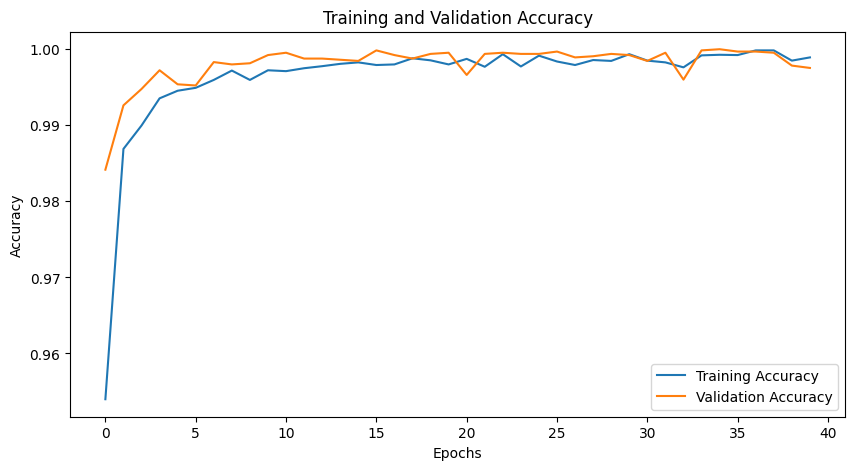

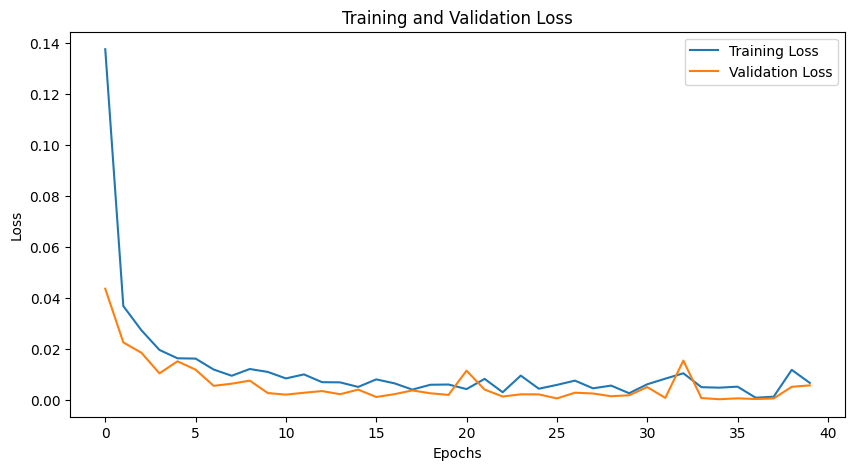

In [7]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

## Confusion matrix

204/204 [==============================] - 3s 13ms/step


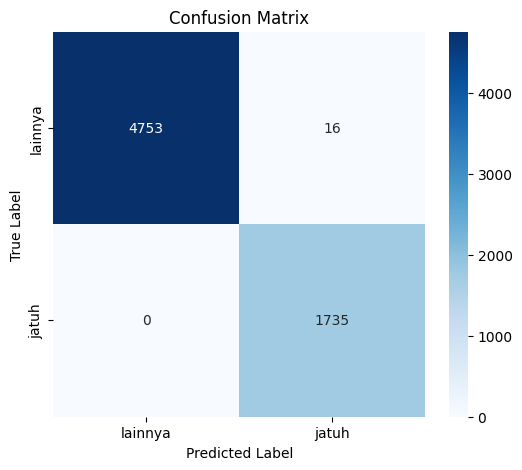

              precision    recall  f1-score   support

     lainnya       1.00      1.00      1.00      4769
       jatuh       0.99      1.00      1.00      1735

    accuracy                           1.00      6504
   macro avg       1.00      1.00      1.00      6504
weighted avg       1.00      1.00      1.00      6504



In [8]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["lainnya", "jatuh"], yticklabels=["lainnya", "jatuh"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=["lainnya", "jatuh"]))

## Export model

In [10]:
model_save_path_h5 = './TCN_Model.h5'
# model_save_path_keras = '/content/drive/MyDrive/Colab Notebooks/TCN_model.keras'
model.save(model_save_path_h5)
# save_model(model, model_save_path_keras)
print(f"Model saved to {model_save_path_h5}")

Model saved to ./TCN_Model.h5
